In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd ..

/Users/leonmac/Codes/BO-Set


In [3]:
import os
import torch
import random
import pandas as pd
import matplotlib
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import multiprocessing
from itertools import product
from publib import set_style, fix_style
set_style(['article'])  

matplotlib.rcParams.update({'font.size': 22})
#plt.rcParams['text.usetex'] = True
#matplotlib.rcParams.update(matplotlib.rcParamsDefault)


supported_labels = ["random", "local_search", "dfs", "bfs", 
                    "polynomial","polynomial_suminverse","diffusion","diffusion_ard"]
# cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']))

d_color = {"polynomial":"#1f77b4", "diffusion_ard":"#8c564b", 
           "polynomial_suminverse":"#e377c2", "diffusion":"#7f7f7f",
           "random":"#ff7f0e", "local_search":"#2ca02c", "dfs": "#d62728", "bfs": "#9467bd"} 
d_label = {"polynomial":"BO_Poly", "polynomial_suminverse":"BO_SumInverse", 
           "diffusion_ard":"BO_Diff_ARD", "diffusion":"BO_Diff", 
           "random":"Random", "local_search":"Local search", "dfs": "Dfs", "bfs": "Bfs"}

title_font=30
my_font=28
tick_font=25
xlim=150

In [4]:
def plot_result(ax, path: str, label: str, plot_kwargs: dict = None, median=False,
                std=False, cumulative=True, regret=True, minimization=False, xlim=None):
    # path: main directory of experiments (eg. logs/centrality), label : label experiment to plot
    exp_dir = os.path.join(path, label)
    algorithm_name = [name for name in os.listdir(exp_dir) if os.path.isdir(os.path.join(exp_dir, name))]
    if len(algorithm_name) == 8:
        algorithm_name=['local_search', 'dfs', 'bfs', 'random',
                        'diffusion', 'diffusion_ard', 'polynomial_suminverse', 'polynomial']
    min_max_len = np.inf
    tick_size = 25
    my_font = 28
    for algorithm in algorithm_name:
        alg_dir = os.path.join(exp_dir, algorithm)
        ## Here are in directory with signal png and pt
        plot_kwargs = deepcopy(plot_kwargs) or {}
        data_path_seeds = [f for f in os.listdir(alg_dir) if ".pt" in f]
        data_over_seeds = []
        for i, df in enumerate(data_path_seeds):
            data_path = os.path.join(alg_dir, df)
            with open(data_path, "rb") as fp:
                data = torch.load(data_path, map_location="cpu")
                minimize = False
            if "regret" in data.keys() and regret and data["regret"] != None:
                y = -data["regret"].numpy().flatten()   # to maximize negative regret
                minimize = True
            else:
                assert "Y" in data.keys()
                y = data["Y"].numpy().flatten()
            if minimization:
                minimize = True
            data_over_seeds.append(y)
        n_data_per_trial = np.array([len(d) for d in data_over_seeds])
        max_len = max(n_data_per_trial)
        if len(np.unique(n_data_per_trial)) > 1:
            # pad as appropriate
            for i, d in enumerate(data_over_seeds):
                data_over_seeds[i] = np.concatenate((
                    d, d[-1] * np.ones(max_len - d.shape[0])))
        all_data = np.array(data_over_seeds)
        if cumulative:
            y = pd.DataFrame(all_data).cummax(axis=1)
        else:
            y = pd.DataFrame(all_data)
        x = np.arange(all_data.shape[1])
        if median:
            mean = y.median(axis=0)
            lb = y.quantile(q=0.25, axis=0)
            ub = y.quantile(q=0.75, axis=0)
        elif std:
            mean = y.mean(axis=0)
            # standard error
            lb = mean - y.std(axis=0)
            ub = mean + y.std(axis=0)
        else:
            mean = y.mean(axis=0)
            # standard error
            lb = mean - y.std(axis=0) / np.sqrt(all_data.shape[0])
            ub = mean + y.std(axis=0) / np.sqrt(all_data.shape[0])
        if minimize:
            mean = -mean
            lb = -lb
            ub = -ub
        ax.plot(x[:xlim+1], mean[:xlim+1], ".-", label=d_label[algorithm], color=d_color[algorithm], **plot_kwargs)
        if "alpha" in plot_kwargs.keys():
            del plot_kwargs["alpha"]
        if "markevery" in plot_kwargs.keys():
            del plot_kwargs["markevery"]
        ax.fill_between(x[:xlim+1], lb[:xlim+1], ub[:xlim+1], alpha=0.1, color=d_color[algorithm], **plot_kwargs)
        ax.plot(x[:xlim+1], lb[:xlim+1], "-", alpha=0.2, color=d_color[algorithm], **plot_kwargs)
        ax.plot(x[:xlim+1], ub[:xlim+1], "-", alpha=0.2, color=d_color[algorithm], **plot_kwargs)
        min_max_len = min(min_max_len, max_len)
    #ax.legend()
    #ax.set_xlabel("\#Iters", fontsize=my_font)
    #ax.set_ylabel("Regret", fontsize=my_font)
    ax.tick_params(axis='both', labelsize=tick_size)
    #ax.set_xlim([0, min_max_len])
    ax.set_xlim([0, xlim])
    #ax.grid()
    #plt.yscale("log")
    
    #plt.savefig(os.path.join(exp_dir, "plot_result_regretpng.png"), bbox_inches='tight')
    #plt.savefig(os.path.join(exp_dir, "plot_result_regretpdf.pdf"), bbox_inches='tight')
    #plt.clf()
    #return y, max_len

# BA Graph Centrality

In [5]:
def plot_ba():
    save_path = f'experiment_figs/Useless/'
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    list_experiences = [
    f"ws_eigenvector_centrality_n-1000_k-5_wsk-10_p-0.1_ninit-10_failtol-30_Q-2000_start-random_restart-same_as_start_query-500",
    f"ws_eigenvector_centrality_n-1000_k-5_wsk-10_p-0.1_ninit-10_failtol-30_Q-2000_start-random_restart-queried_best_query-500",
    f"ba_eigenvector_centrality_n-10002_k-5_m-5_ninit-1_failtol-30_Q-2000_start-random_query-500",
    f"ba_eigenvector_centrality_n-10002_k-5_m-5_ninit-1_failtol-30_Q-2000_start-random_restart-same_as_startquery-500",

    f"ba_eigenvector_centrality_n-10000_k-50_m-5_ninit-10_failtol-30_Q-1000_query-500",
    f"ba_eigenvector_centrality_n-10000_k-50_m-5_ninit-10_failtol-30_Q-1000_query-500",
    f"ba_eigenvector_centrality_n-10001_k-50_m-5_ninit-10_failtol-30_Q-2000_start-random_query-500",
    f"ba_eigenvector_centrality_n-10001_k-50_m-5_ninit-10_failtol-30_Q-2000_start-random_query-500",
    
    f"contact_network_day1_infection_time_k-5_threshold-0.5_samples-100_iter-200_ninit-5_failtol-30_Q-2000_start-random_query-500",
    f"contact_network_day1_infection_time_k-5_threshold-0.5_samples-100_iter-200_ninit-5_failtol-30_Q-2000_start-ei_query-500",
    f"contact_network_day1_infection_time_k-5_threshold-0.5_samples-100_iter-200_ninit-1_failtol-30_Q-2000_start-random_restart-queried_bestquery-500",
    f"contact_network_day1_infection_time_k-4_threshold-0.3_samples-50_iter-400_ninit-10_failtol-30_Q-500_query-200",    
    
    f"contact_network_day1_infection_time_k-20_threshold-0.5_samples-100_iter-200_ninit-1_failtol-30_Q-2000_start-random_restart-queried_best_query-500",
    f"contact_network_day1_infection_time_k-20_threshold-0.5_samples-100_iter-200_ninit-1_failtol-30_Q-2000_start-betweenness_restart-queried_best_query-500",
    f"contact_network_day1_infection_time_k-20_threshold-0.3_samples-50_iter-400_ninit-5_failtol-10_Q-2000_query-500",
    ]
    n_rows, n_cols = 4, 4
    title_font=30
    #fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(20, 8))
    fig, axs = plt.subplots(n_rows, n_cols, layout='constrained', figsize=(24, 20))
    for i, experience in enumerate(list_experiences):
        idx_row, idx_col = i // n_cols, i % n_cols
        #print(idx_row, idx_col)

        plot_result(axs[idx_row, idx_col], "./logs/useless/", list_experiences[i], 
                    median=False, std=False, xlim=500)

    handles, labels = axs[idx_row, idx_col].get_legend_handles_labels()
    #change_labels = [0, 1, 5, 7, 2, 3, 6, 4 ]
    #labels = [labels[i] for i in change_labels]
    #handles = [handles[i] for i in change_labels]

    axs[0, 0].set_title('WS '+r'$n=1k$; ' + r'$k = 5$', fontsize=title_font)
    #axs[0, 0].text(20, 0.5 , r'$sm=21$')
    axs[0, 0].set_ylabel("Regret", fontsize=my_font)
    axs[0, 1].set_title('WS '+r'$n=1k$; ' + r'$k = 5$', fontsize=title_font)
    #axs[0, 1].text(20, 0.17, r'$sm=33$')
    axs[0, 2].set_title('BA '+r'$n=10k$; ' + r'$k = 5$', fontsize=title_font)
    #axs[0, 2].text(20, 0.11, r'$sm=51$')
    axs[0, 3].set_title('BA '+r'$n=10k$; ' + r'$k = 5$', fontsize=title_font)

    
    axs[1, 0].set_title('BA '+r'$n=10k$; ' + r'$k = 50$', fontsize=title_font)
    #axs[1, 0].text(20, 0.35, r'$sm=25$')
    axs[1, 0].set_ylabel("Regret", fontsize=my_font)
    axs[1, 0].set_xlabel("#Queries", fontsize=my_font)
    
    axs[1, 1].set_title('BA '+r'$n=10k$; ' + r'$k = 50$', fontsize=title_font)
    #axs[1, 1].text(20, 0.32, r'$sm=34$')
    axs[1, 1].set_xlabel("#Queries", fontsize=my_font)
    
    axs[1, 2].set_title('BA '+r'$n=10k$; ' + r'$k = 50$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[1, 2].set_xlabel("#Queries", fontsize=my_font)
    
    
    axs[2, 0].set_title(r'$Contact$; ' + r'$k = 5$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[2, 0].set_xlabel("#Queries", fontsize=my_font)
    
    axs[2, 1].set_title(r'$Contact$; EI ' + r'$k = 5$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[2, 1].set_xlabel("#Queries", fontsize=my_font)

    axs[2, 2].set_title(r'$Contact$; ' + r'$k = 5$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[2, 2].set_xlabel("#Queries", fontsize=my_font)
    
    axs[2, 3].set_title(r'$Contact$ Attack; ' + r'$k = 4$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[2, 3].set_xlim([0,200])
    axs[2, 3].set_xlabel("#Queries", fontsize=my_font)

    axs[3, 0].set_title(r'$Contact$ ; ' + r'$k = 20$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[3, 0].set_xlabel("#Queries", fontsize=my_font)

    axs[3, 1].set_title(r'$Contact$ ; Be ' + r'$k = 20$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[3, 1].set_xlabel("#Queries", fontsize=my_font)

    axs[3, 2].set_title(r'$Contact$ Attack; ' + r'$k = 20$', fontsize=title_font)
    #axs[1, 2].text(20, 0.26, r'$sm=48$')
    axs[3, 2].set_xlabel("#Queries", fontsize=my_font)    

    fig.legend(handles = handles, labels=labels, loc='upper center', bbox_to_anchor=(0.5, 0.), 
               frameon=True, fancybox=False, shadow=False, ncol=8, fontsize=tick_font-2)

    fix_style('article')
    plt.tight_layout()
    plt.savefig(f"{save_path}centrality_ba.pdf", bbox_inches='tight')
    plt.savefig(f"{save_path}centrality_ba.png", bbox_inches='tight')
    plt.savefig(f"{save_path}centrality_ba.jpg", bbox_inches='tight')

    #plt.show()

/Users/leonmac/anaconda3/lib/python3.11/site-packages/publib/main.py:230: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/var/folders/0p/p2rtjxnd3hgc3cf2jvwg_1fm0000gn/T/ipykernel_64206/1617608465.py:98: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


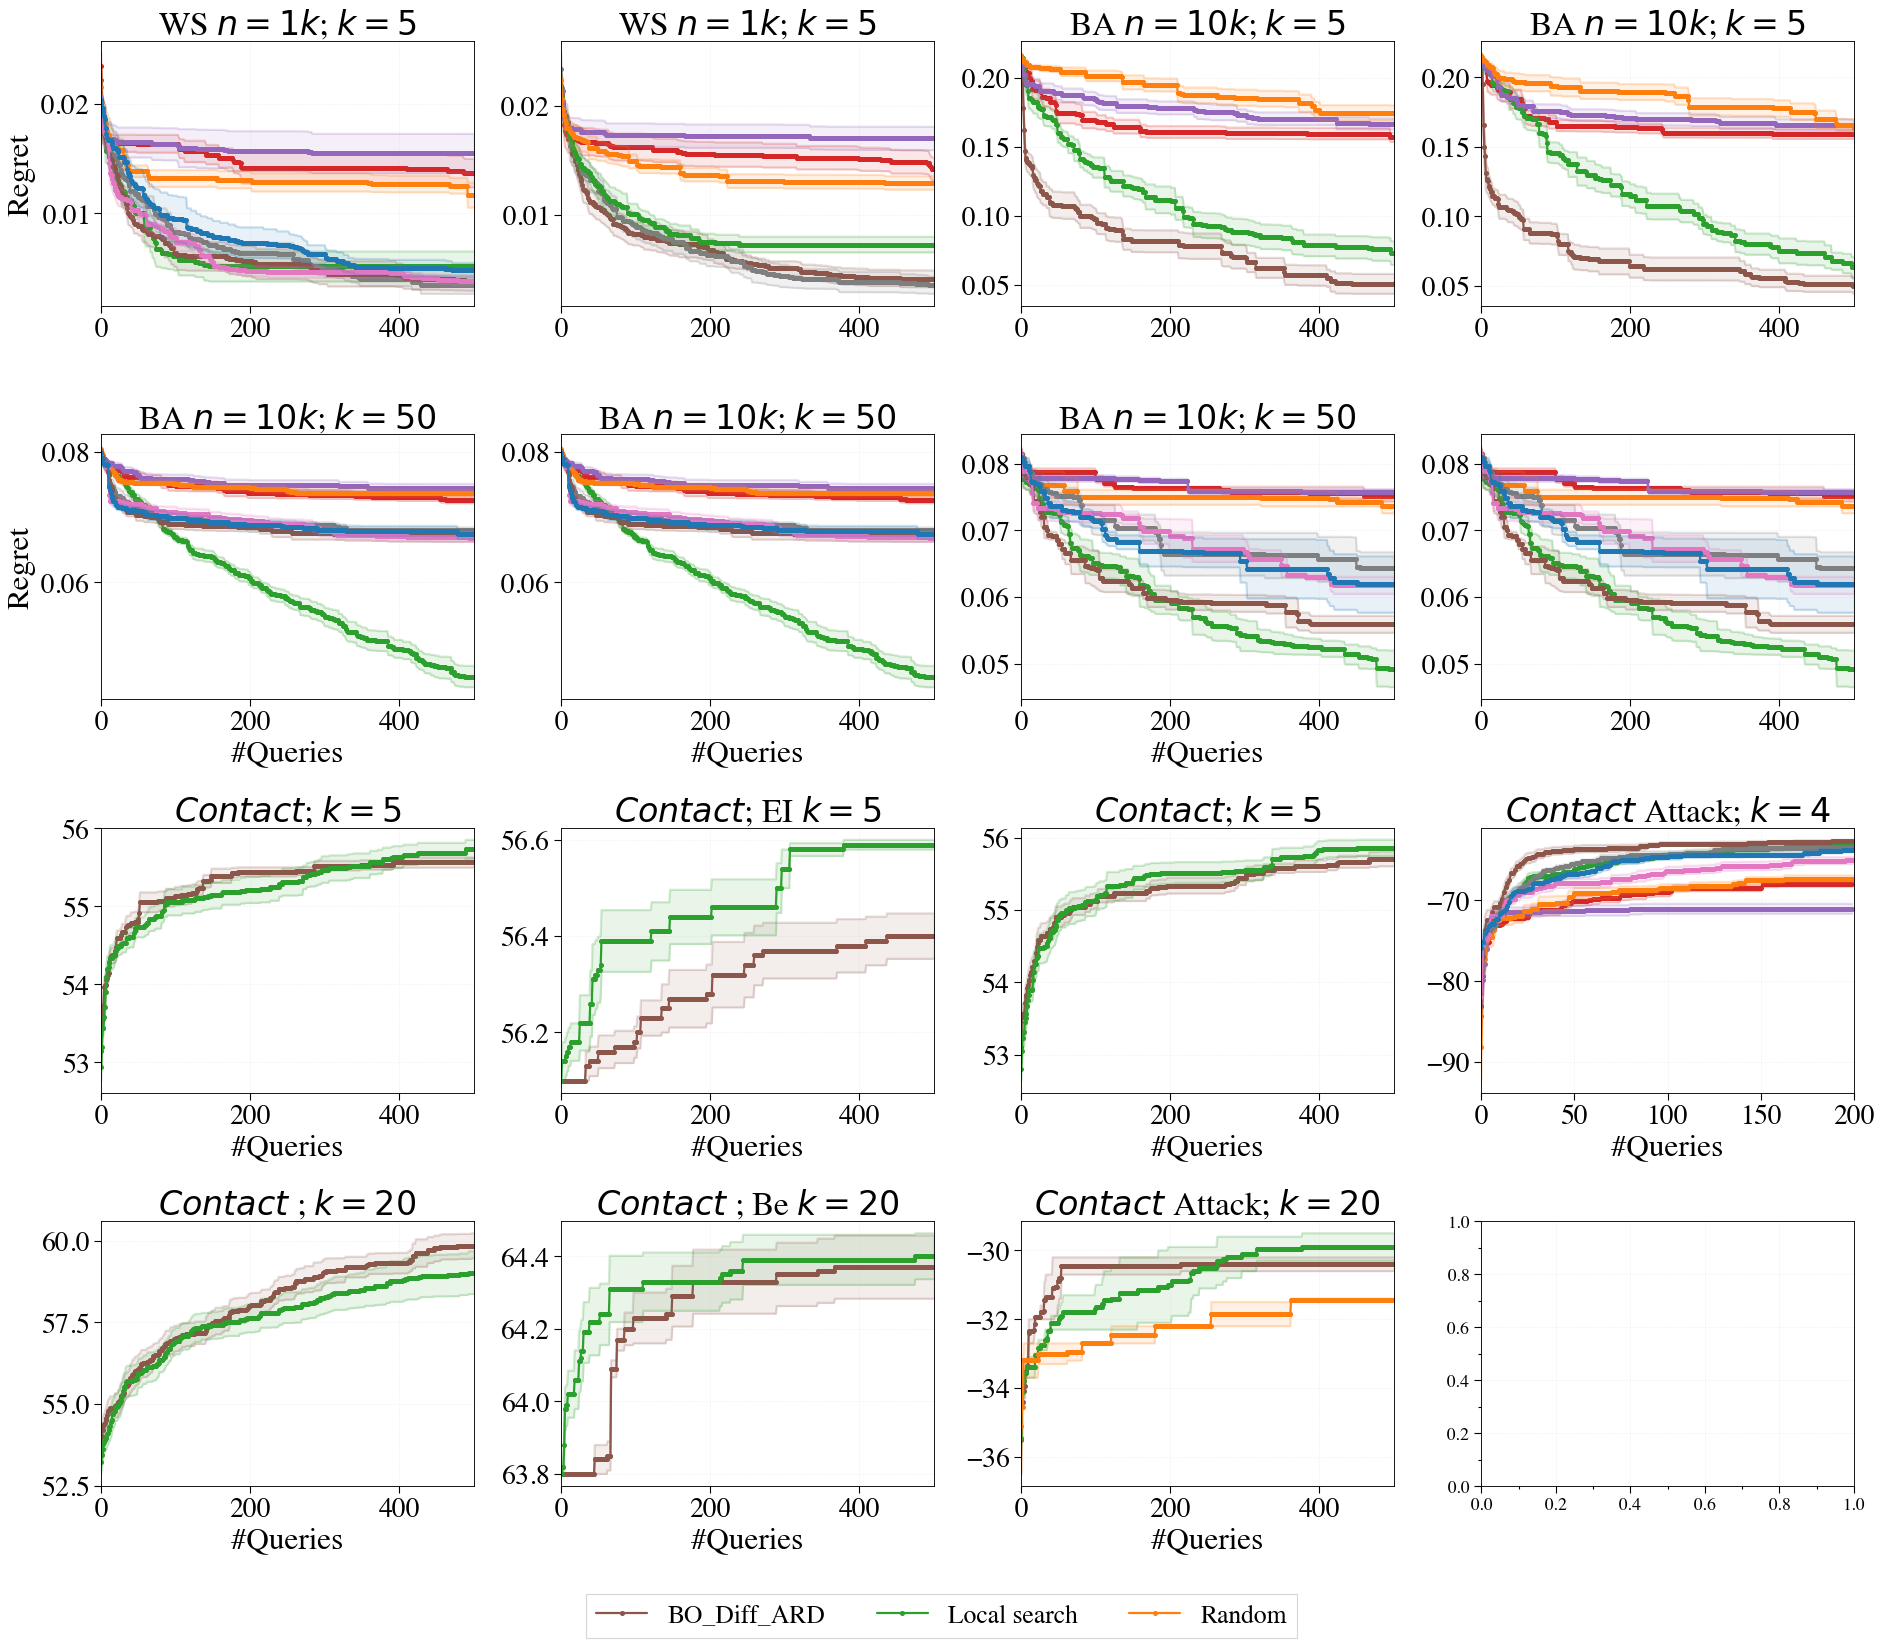

In [6]:
plot_ba()

In [7]:
def func(i):
    if i==2:
        return np.array([1,2])
    else:
        return np.empty(shape=(0,2),dtype=int)
x=list(map(func,[2,2,1,2,2]))
print(x)

[array([1, 2]), array([1, 2]), array([], shape=(0, 2), dtype=int64), array([1, 2]), array([1, 2])]


In [8]:
np.array(x)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (5,) + inhomogeneous part.

In [ ]:
my_list=[(2,3),(3,3),(1,5)]

In [ ]:
random.shuffle(my_list)

In [ ]:
my_list

#failtol_list = [10, 20, 30, 40]
#Q_list = [20, 50, 100, 200]

failtol_list = [30]
Q_list = [200]

input_data = list(product(failtol_list, Q_list))

with multiprocessing.Pool() as pool:
    #pool.starmap(plot_test, input_data)
    pool.starmap(plot_ba, input_data)
    #pool.starmap(plot_ws, input_data)

# Test Function